# 1. Setup & Environment
- 공간 데이터 처리 및 카토그래피 렌더링 라이브러리(GeoPandas, Matplotlib) 로드
- 한글 폰트(NanumGothic) 및 유니코드 마이너스 부호 환경 구성

In [1]:
# 1. 라이브러리 로드 및 환경 설정
from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

# 폰트 및 유니코드 설정
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# 2. Configuration & Quadrant Palette Definitions
- 집계구 폴리곤 및 4분면 분류 CSV 입출력 디렉터리(`output/maps`) 설정
- 학술 논문 및 정책 진단 표준 4분면 컬러 팔레트 정의
  * 미스매치(EV만 급증): Crimson Red (`#d73027`, 최우선 정책 개입 대상)
  * 균형성장(둘 다 급증): Green (`#1a9850`, 인프라 추종 양호)
  * 선제공급(충전소만 급증): Navy Blue (`#2166ac`, 공급 여력 확보)
  * 저성장(둘 다 완만): Light Gray (`#f0f0f0`, 배경 비강조)

In [2]:
# 2. 경로 및 스타일 팔레트 정의
BASE_DIR = Path("/mnt/cowork/EV")
BOUNDARY_FP = BASE_DIR / "input/raw/집계구_2016/집계구.shp"

# 4분면 산출물 경로 (표준 출력 디렉터리 우선 탐색)
QUAD_FP_OUT = BASE_DIR / "output/ev_charger_dong_quadrant.csv"
QUAD_FP_TMP = Path("/tmp/ev_charger_dong_quadrant.csv")
QUAD_FP = QUAD_FP_OUT if QUAD_FP_OUT.exists() else QUAD_FP_TMP

DIR_MAPS = BASE_DIR / "output/maps"
DIR_MAPS.mkdir(parents=True, exist_ok=True)
OUT_FP_MW = DIR_MAPS / "ev_charger_mismatch_mw.png"

# 서울시 25개 자치구 코드 매핑 테이블
GU_MAP = {
    "11010": "종로구", "11020": "중구", "11030": "용산구", "11040": "성동구", "11050": "광진구",
    "11060": "동대문구", "11070": "중랑구", "11080": "성북구", "11090": "강북구", "11100": "도봉구",
    "11110": "노원구", "11120": "은평구", "11130": "서대문구", "11140": "마포구", "11150": "양천구",
    "11160": "강서구", "11170": "구로구", "11180": "금천구", "11190": "영등포구", "11200": "동작구",
    "11210": "관악구", "11220": "서초구", "11230": "강남구", "11240": "송파구", "11250": "강동구",
}

# 4분면 시각화 팔레트
COLOR_MAP = {
    "미스매치(EV만 급증)": "#d73027",  # Crimson Red (정책적 병목 소외 지역)
    "균형성장": "#1a9850",             # Forest Green (공급-수요 동반 성장)
    "선제공급": "#2166ac",             # Navy Blue (충전 인프라 선도 지역)
    "저성장": "#f0f0f0",               # Light Gray (비강조 배경)
}

BORDER_COLOR = "#bdbdbd"
TEXT_COLOR = "#222222"
MUTED_COLOR = "#666666"

print(f">> 입력 데이터: {QUAD_FP.resolve()}")
print(f">> 출력 대상 맵 파일: {OUT_FP_MW.name}")

>> 입력 데이터: /tmp/ev_charger_dong_quadrant.csv
>> 출력 대상 맵 파일: ev_charger_mismatch_mw.png


# 3. Spatial Boundary & Quadrant Data Alignment
- 서울시 14,979개 집계구 폴리곤(EPSG:5179) 로드 및 `gu + ADM_NM` 복합키 생성
- 행정동 단위 4분면 분류 테이블 병합 및 결측치('저성장') 처리

In [3]:
# 3. 집계구 경계 및 4분면 데이터 결합
def load_and_merge_quadrant(boundary_path: Path, quad_path: Path) -> gpd.GeoDataFrame:
    """서울시 집계구 폴리곤에 행정동 4분면 유형 속성을 결합"""
    gdf = gpd.read_file(boundary_path)
    gdf = gdf.set_crs(epsg=5179, allow_override=True)
    gdf["TOT_REG_CD"] = gdf["TOT_REG_CD"].astype(str)
    
    # 서울시 집계구 필터링 및 복합키 생성 (구명 + 행정동명)
    gdf_seoul = gdf[gdf["TOT_REG_CD"].str.startswith("11")].copy().reset_index(drop=True)
    gdf_seoul["gu"] = gdf_seoul["TOT_REG_CD"].str[:5].map(GU_MAP)
    gdf_seoul["dong_key2"] = gdf_seoul["gu"] + gdf_seoul["ADM_NM"]

    # 4분면 데이터 로드
    if not quad_path.exists():
        raise FileNotFoundError(f"4분면 데이터 파일이 존재하지 않습니다: {quad_path}")
        
    df_quad = pd.read_csv(quad_path)
    if "dong_key2" not in df_quad.columns:
        df_quad["dong_key2"] = df_quad["gu"] + df_quad["ADM_NM"]

    # 공간 결합 및 미분류 지역 처리
    gdf_merged = gdf_seoul.merge(df_quad[["dong_key2", "quad"]], on="dong_key2", how="left")
    gdf_merged["quad"] = gdf_merged["quad"].fillna("저성장")
    
    return gdf_merged

gdf_mismatch = load_and_merge_quadrant(BOUNDARY_FP, QUAD_FP)
print(f">> 공간 결합 완료: 총 {len(gdf_mismatch):,}개 집계구 매핑")

>> 공간 결합 완료: 총 19,153개 집계구 매핑


# 4. Cartographic Mismatch Map Generation & High-Res Export
- 집계구 경계 노이즈 제거를 위한 군집 디졸브(Dissolve) 및 위상 정제
- 레이어 렌더링 우선순위(Z-order) 제어로 미스매치 지역 돌출
- 논문/포스터 규격(300 DPI) 고해상도 이미지(`ev_charger_mismatch_mw.png`) 저장

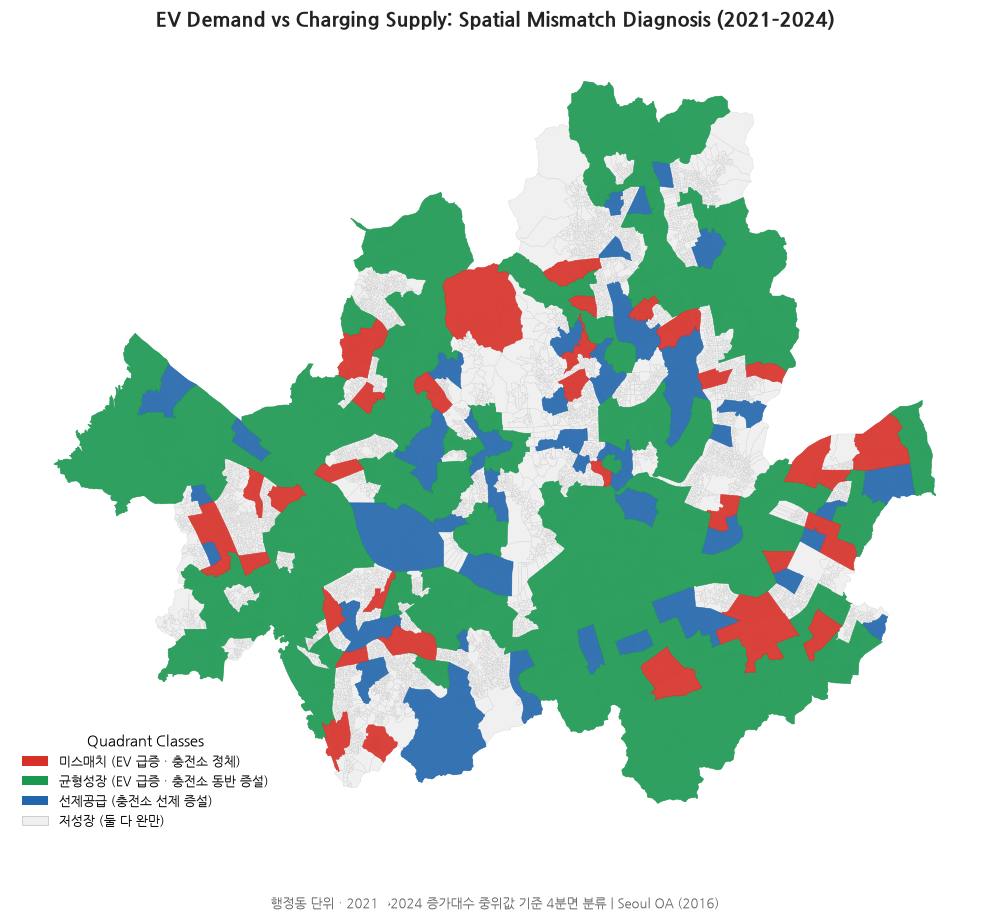

>> 미스매치 진단 지도 고해상도 저장 완료: /mnt/cowork/EV/output/maps/ev_charger_mismatch_mw.png


In [4]:
# 4. 미스매치 진단 지도 렌더링 및 내보내기
fig, ax = plt.subplots(figsize=(10, 10), facecolor="white")

# 1. 기본 배경 집계구 렌더링 (저성장 기본 배경)
gdf_mismatch.plot(
    ax=ax, 
    color=COLOR_MAP["저성장"], 
    edgecolor=BORDER_COLOR, 
    linewidth=0.15
)

# 2. 위상 정제 및 4분면 군집별 디졸브 플롯
dissolved = gdf_mismatch.dissolve(by="quad")
dissolved["geometry"] = dissolved.geometry.buffer(1).buffer(-1)

# 레이어 중첩 순서 (정책 핵심인 미스매치를 최상단에 배치)
RENDER_ORDER = ["선제공급", "균형성장", "미스매치(EV만 급증)"]

for key in RENDER_ORDER:
    if key in dissolved.index:
        dissolved.loc[[key]].plot(
            ax=ax, 
            facecolor=COLOR_MAP[key], 
            edgecolor=COLOR_MAP[key], 
            linewidth=0.4, 
            alpha=0.90
        )

ax.set_axis_off()

# 3. 헤더 및 캡션 설정
ax.set_title(
    "EV Demand vs Charging Supply: Spatial Mismatch Diagnosis (2021–2024)",
    fontsize=14.5, fontweight="bold", color=TEXT_COLOR, pad=14
)

# 4. 하단 좌측 범례 구성
legend_handles = [
    mpatches.Patch(facecolor=COLOR_MAP["미스매치(EV만 급증)"], label="미스매치 (EV 급증 · 충전소 정체)"),
    mpatches.Patch(facecolor=COLOR_MAP["균형성장"], label="균형성장 (EV 급증 · 충전소 동반 증설)"),
    mpatches.Patch(facecolor=COLOR_MAP["선제공급"], label="선제공급 (충전소 선제 증설)"),
    mpatches.Patch(facecolor=COLOR_MAP["저성장"], edgecolor=BORDER_COLOR, linewidth=0.5, label="저성장 (둘 다 완만)"),
]

ax.legend(
    handles=legend_handles, 
    loc="lower left", 
    frameon=False, 
    fontsize=9.5,
    title="Quadrant Classes",
    title_fontsize=10.5
)

fig.text(
    0.5, 0.04, 
    "행정동 단위 · 2021→2024 증가대수 중위값 기준 4분면 분류 | Seoul OA (2016)", 
    ha="center", fontsize=9.5, color=MUTED_COLOR
)

# 300 DPI 저장 및 화면 출력
fig.tight_layout(rect=[0, 0.03, 1, 0.98])
fig.savefig(OUT_FP_MW, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f">> 미스매치 진단 지도 고해상도 저장 완료: {OUT_FP_MW}")

# 5. Quadrant Distribution Summary Statistics
- 서울시 전체 행정동 및 집계구 기준 4분면 유형별 분포 빈도 및 비율(%) 요약표 출력

In [5]:
# 5. 유형별 통계 집계표 출력
df_dong_unique = gdf_mismatch.drop_duplicates(subset=["dong_key2"])[["gu", "ADM_NM", "quad"]]

summary_dong = df_dong_unique["quad"].value_counts().rename("행정동_수")
summary_oa = gdf_mismatch["quad"].value_counts().rename("집계구_수")

df_quad_stat = pd.concat([summary_dong, summary_oa], axis=1).fillna(0).astype(int)
df_quad_stat["행정동_비율(%)"] = (df_quad_stat["행정동_수"] / len(df_dong_unique)) * 100.0
df_quad_stat["집계구_비율(%)"] = (df_quad_stat["집계구_수"] / len(gdf_mismatch)) * 100.0

print("=" * 80)
print("             2021→2024 EV vs 충전소 4분면 유형별 공간 분포 요약표")
print("=" * 80)
display(df_quad_stat[["행정동_수", "행정동_비율(%)", "집계구_수", "집계구_비율(%)"]])

             2021→2024 EV vs 충전소 4분면 유형별 공간 분포 요약표


,행정동_수,행정동_비율(%),집계구_수,집계구_비율(%)
quad,,,,
균형성장,159,37.500000,8646,45.141753
저성장,151,35.613208,5668,29.593275
선제공급,63,14.858491,2458,12.833499
미스매치(EV만 급증),51,12.028302,2381,12.431473


# 6. Output Verification
- 생성된 300 DPI 고해상도 래스터 이미지 파일의 경로 및 파일 용량(MB) 무결성 검증

In [6]:
# 6. 산출물 파일 상태 확인
if OUT_FP_MW.exists():
    file_size_mb = OUT_FP_MW.stat().st_size / (1024 * 1024)
    print("=" * 70)
    print(f"  파일명    : {OUT_FP_MW.name}")
    print(f"  절대 경로 : {OUT_FP_MW.resolve()}")
    print(f"  파일 크기 : {file_size_mb:.2f} MB")
    print("  상태      : 정상 저장 완료 (포스터 및 보고서 삽입 규격 충족)")
    print("=" * 70)
else:
    print(f"[!] 파일 저장 실패: {OUT_FP_MW}")

  파일명    : ev_charger_mismatch_mw.png
  절대 경로 : /mnt/cowork/EV/output/maps/ev_charger_mismatch_mw.png
  파일 크기 : 2.15 MB
  상태      : 정상 저장 완료 (포스터 및 보고서 삽입 규격 충족)
